In [1]:
import pandas as pd
import numpy as np

In [2]:
# If you meant pandas as pd and wanted to read a CSV
# filepath: replace with your file path
df = pd.read_csv("Cellphone.csv")
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


### EDA part - 1

- Now we will be doing the gathering all the information about the project try to understand what it has to be done

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [4]:
df.isnull().sum()

Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

In [5]:
df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


#### Find the outliers in all the columns

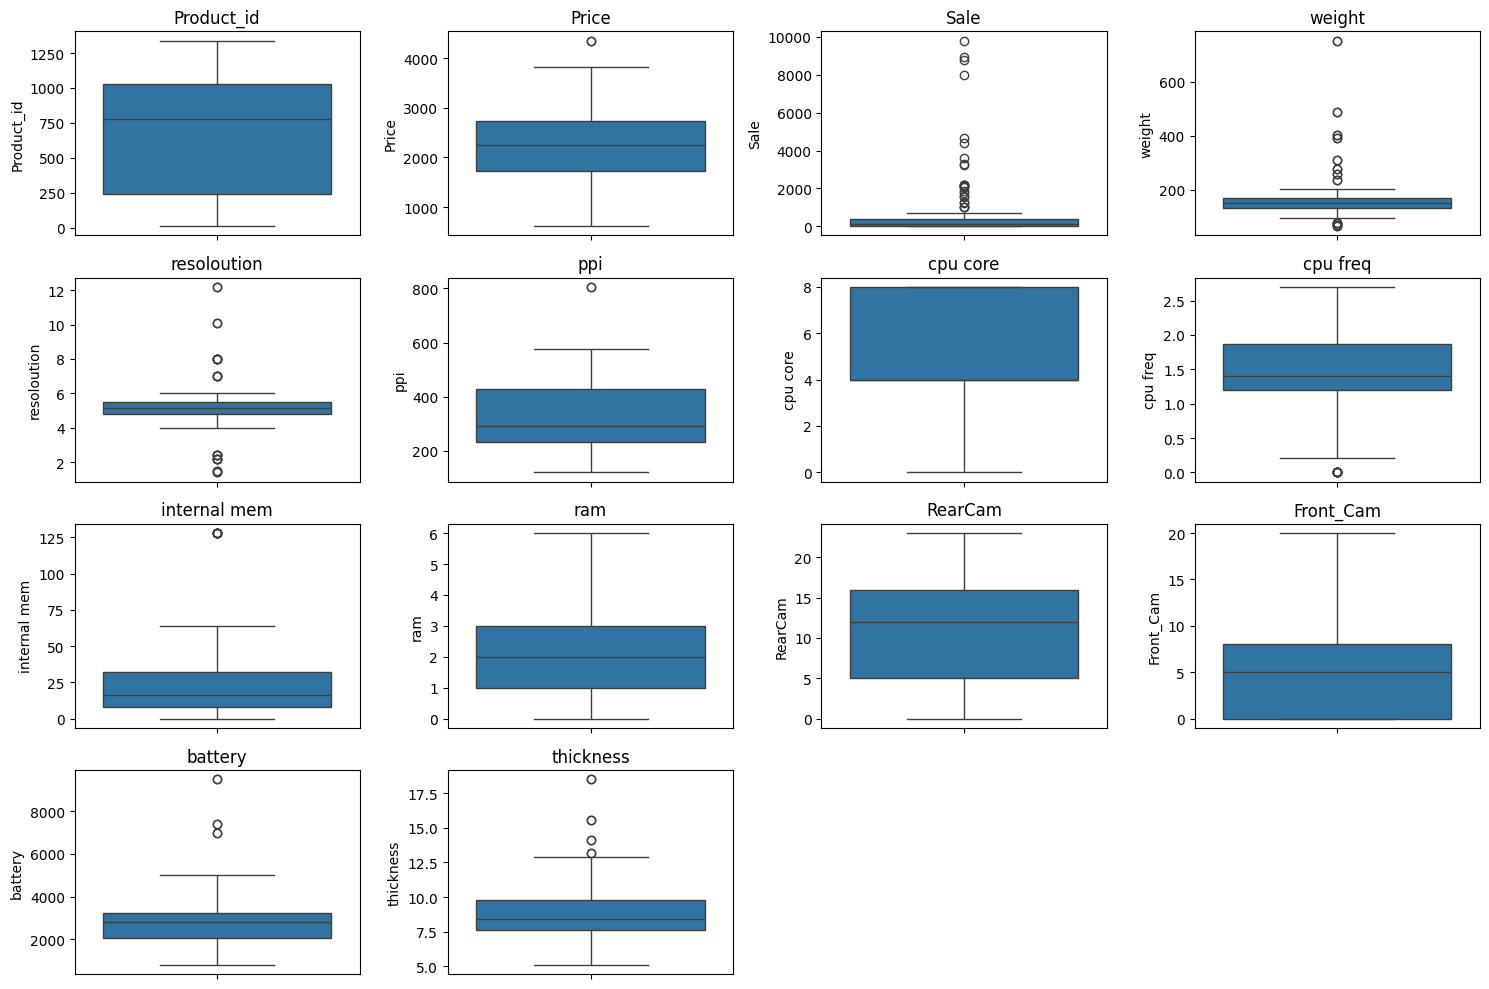

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

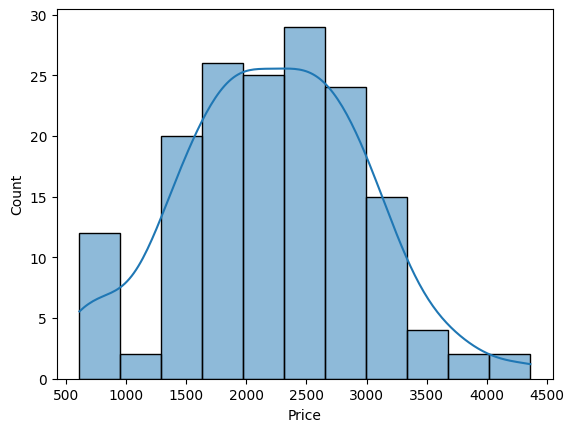

In [7]:
plt.Figure(figsize=(10, 6))

sns.histplot(df["Price"], kde=True)
plt.show()

#### See the correlation of the data

In [8]:
# no  we will see the correlation between the price and other features
target_corr = df.drop(columns = 'Price').corrwith(df["Price"])

corr_df = target_corr.to_frame(name='Correlation')

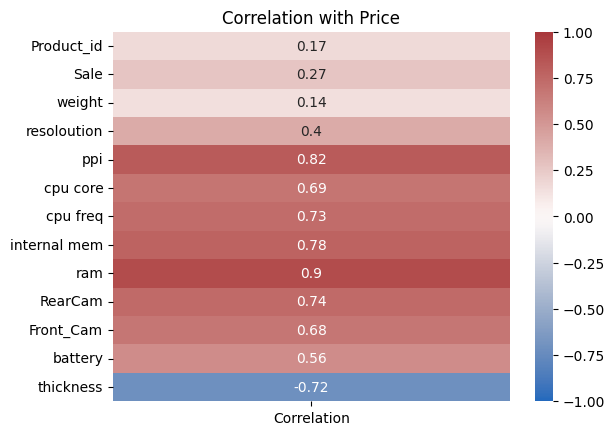

In [9]:
sns.heatmap(corr_df, annot=True, cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Correlation with Price')
plt.show()

Above plot we could see that correlation with the target data i.e. price, let's each  

Text(0.5, 1.0, 'Multicollinearity Heatmap')

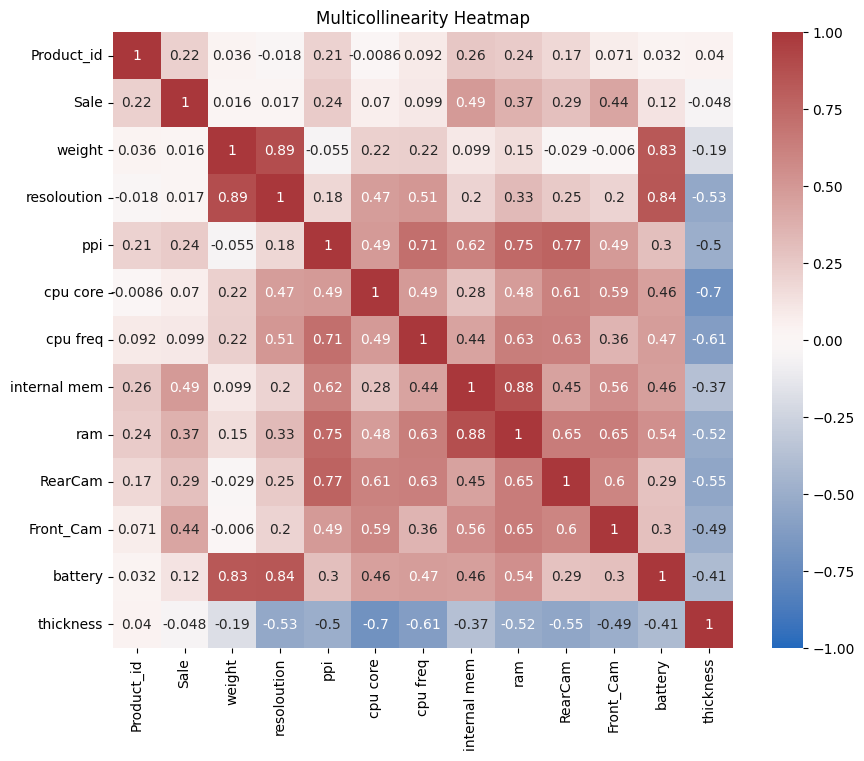

In [10]:
plt.figure(figsize=(10, 8))
multicolearity = df.drop(columns='Price').corr()
sns.heatmap(multicolearity, annot=True, cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Multicollinearity Heatmap')

here we see all highly correlated parameter:
 - more than .8(very Highly correlated):
   - weight & resolution
   - weight & battery
   - battery &  resolution
 - between .7 and .8 (very low correlated):
   - cpu freq & ppi
   - ram & ppi
   - RearCam & ppi

In [11]:
# Now we will divide the feature where we Input data in X and the target variable in y
X = df.drop(columns='Price', axis=1)
X.drop("Product_id",axis=1, inplace=True)
X.head()

,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [12]:
# here we will also see the collinearity with VIF aka variance inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data.sort_values(by="VIF", ascending=False)

,feature,VIF
2,resoloution,113.761945
1,weight,63.305091
10,battery,50.477631
3,ppi,32.586559
5,cpu freq,27.887919
7,ram,26.782572
4,cpu core,14.557883
8,RearCam,14.537316
6,internal mem,11.742283
11,thickness,8.803232


- as you after doing variance inflation factor we will now could see that some of the features are showing way too high VIF values so it may have high multi colinearity
- but we can't remove the features as they are really co realated and the we have 161 rows in the dataset.
- but here you could see that we should drop sale and resolution, cause in sale we can only see after there demand and also:
 - if the phone is cheap and sales goes then it's no use of it 
 - for resolution we could see that ppi can also does the same work as resolution does so we should remove the resolution feature as well

In [13]:
X.drop(columns=['Sale','resoloution'],inplace=True)
y = df['Price']
X.head()

,weight,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,135.0,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,125.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,110.0,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,118.5,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,125.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [14]:
X.describe()

,weight,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,170.426087,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,92.888612,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,66.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,134.100000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,153.000000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,170.000000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,753.000000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


- here I could see some *supicious* thing the dataset as some features like `cpu freq`, `internal mem` and `ram` as without these features It can't be possible to run a mobile phone I can't possible that they have zero in mobile
- Now in `RearCam` and `Front_Cam` may or may not have zero value on the basis of price:
    - if it is cheap mobile phone then both won't be there
    - but if it is pricey then it has to be there

- for this we have imply different imputation technique in which we mostly prefer either KNN imputer or we will put the median value

In [15]:
print((X['cpu core'] == 0).sum())
print((X['cpu freq'] == 0).sum())
print((X['internal mem'] == 0).sum())
print((X['ram'] == 0).sum())


10
10
10
2


- here we see that that `CPU core`, `cpu freq`, `internal mem`, `ram` have 10, 10, 10 and 2 zero in data

##### imputation on zeros

In [16]:
#we are first taking the data that has zeros in it and replace it with nan values 

cols_with_invalid_zero = [
    'ram',
    'internal mem',
    'cpu freq',
    'cpu core'
]

for col in cols_with_invalid_zero:
    X[col] = X[col].replace(0, np.nan)

In [17]:
X.isnull().sum()

weight           0
ppi              0
cpu core        10
cpu freq        10
internal mem    10
ram              2
RearCam          0
Front_Cam        0
battery          0
thickness        0
dtype: int64

- imputation by Median values

In [18]:
median_impute = X
for col in cols_with_invalid_zero:
    median_impute[col].fillna(median_impute[col].median(), inplace=True)
median_impute.isnull().sum()

C:\Users\Joyal\AppData\Local\Temp\ipykernel_5196\3238568514.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  median_impute[col].fillna(median_impute[col].median(), inplace=True)
C:\Users\Joyal\AppData\Local\Temp\ipykernel_5196\3238568514.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

weight          0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

In [19]:
median_impute.describe()

,weight,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,170.426087,335.055901,5.105590,1.596000,25.495503,2.229839,10.378261,4.503106,2842.111801,8.921739
std,92.888612,134.826659,2.117199,0.458093,28.208469,1.590813,6.181585,4.342053,1366.990838,2.192564
min,66.000000,121.000000,1.000000,0.208000,0.004000,0.004000,0.000000,0.000000,800.000000,5.100000
25%,134.100000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,153.000000,294.000000,4.000000,1.500000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,170.000000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,753.000000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_median_data = pd.DataFrame()
vif_median_data["feature"] = median_impute.columns

vif_median_data["VIF"] = [variance_inflation_factor(median_impute.values, i) for i in range(len(median_impute.columns))]

vif_median_data.sort_values(by="VIF", ascending=False)

,feature,VIF
8,battery,48.258051
1,ppi,29.166775
0,weight,27.963786
5,ram,24.934066
3,cpu freq,24.933815
6,RearCam,13.146666
2,cpu core,11.917211
9,thickness,9.182469
4,internal mem,9.039653
7,Front_Cam,5.007979


- we will also do KNN imputation here below by nearest neighbour of 3

In [21]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)

knn_impute = imputer.fit_transform(X)

In [22]:
knn_imputed = pd.DataFrame(knn_impute, columns=X.columns)
knn_imputed.describe()

,weight,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,170.426087,335.055901,5.105590,1.596000,25.495503,2.229839,10.378261,4.503106,2842.111801,8.921739
std,92.888612,134.826659,2.117199,0.458093,28.208469,1.590813,6.181585,4.342053,1366.990838,2.192564
min,66.000000,121.000000,1.000000,0.208000,0.004000,0.004000,0.000000,0.000000,800.000000,5.100000
25%,134.100000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,153.000000,294.000000,4.000000,1.500000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,170.000000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,753.000000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_knn_data = pd.DataFrame()
vif_knn_data["feature"] = knn_imputed.columns

vif_knn_data["VIF"] = [variance_inflation_factor(knn_imputed.values, i) for i in range(len(knn_imputed.columns))]

vif_knn_data.sort_values(by="VIF", ascending=False)

,feature,VIF
8,battery,48.258051
1,ppi,29.166775
0,weight,27.963786
5,ram,24.934066
3,cpu freq,24.933815
6,RearCam,13.146666
2,cpu core,11.917211
9,thickness,9.182469
4,internal mem,9.039653
7,Front_Cam,5.007979


#### Feature Scalling and Train/Test Split

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



X_train, X_test, y_train, y_test = train_test_split(median_impute, y, test_size=0.2, random_state=42)

scalar = StandardScaler()


X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred_lr = lr.predict(X_test_scaled)

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [28]:
# we will now perform it with different imputed data with linear regression
def output(X, y, imputed_with):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scalar = StandardScaler()
    X_train_scaled = scalar.fit_transform(X_train)
    X_test_scaled = scalar.transform(X_test)
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)

    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

    r2_lr = r2_score(y_test, y_pred_lr)

    print(f"Linear Regression Results with {imputed_with}:")
    print("MAE :", mae_lr)
    print("RMSE:", rmse_lr)
    print("R2  :", r2_lr)


output(median_impute, y, "Median Imputation") # here we see with median imputation how the model performs
output(knn_imputed, y, "KNN Imputation") # here we see with KNN imputation how the model performs

Linear Regression Results with Median Imputation:
MAE : 141.06770583385844
RMSE: 169.75008876398627
R2  : 0.9491697826292773
Linear Regression Results with KNN Imputation:
MAE : 141.06770583385844
RMSE: 169.75008876398627
R2  : 0.9491697826292773


here we could see that even doing both the imputation we could see that 

As we have seen before by linear regression that here we got 94.9 but the feature has too much of mulitcolinearity so we will use ridge and lasso regression to check whether it performs better with these values

In [29]:
# here we will save the performance matrix

training_score_r2 =  []
training_score_mae = []
training_score_rmse = []
training_score_mse = []
training_score_abs_r2 = []

test_score_r2 = []
test_score_mae = []
test_score_rmse = []
test_score_mse = []
test_score_abs_r2 = []


In [30]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet


def evaluate_models(model, X, y):

    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
    scalar = StandardScaler()
    trained_scaled_X = scalar.fit_transform(train_X)
    test_scaled_X = scalar.transform(test_X)
    
    model.fit(trained_scaled_X, train_y)

    test_pred_y = model.predict(test_scaled_X)
    train_pred_y = model.predict(trained_scaled_X)

    #calculate the R2 score for both training and testing data
    train_r2 = r2_score(train_y, train_pred_y) * 100
    test_r2 = r2_score(test_y, test_pred_y) * 100

    #calculate adjusted R2 score for both training and testing data
    n_train, p_train = trained_scaled_X.shape
    n_test, p_test = test_scaled_X.shape
    test_adj_r2 = (1 - (1 - test_r2/100) * (n_test - 1) / (n_test - p_test - 1)) * 100
    train_adj_r2 = (1 - (1 - train_r2/100) * (n_train - 1) / (n_train - p_train - 1)) * 100

    # Calculate MSE, RSME, and MAE for both training and tresting data
    train_mse = mean_squared_error(train_y, train_pred_y)
    test_mse = mean_squared_error(test_y, test_pred_y)

    test_rmse = np.sqrt(test_mse)
    train_rmse = np.sqrt(train_mse)

    train_mae = mean_absolute_error(train_y, train_pred_y)
    test_mae = mean_absolute_error(test_y, test_pred_y)

    training_score_r2.append(train_r2)
    training_score_mae.append(train_mae)
    training_score_rmse.append(train_rmse)
    training_score_mse.append(train_mse)
    training_score_abs_r2.append(train_adj_r2)

    test_score_r2.append(test_r2)
    test_score_mae.append(test_mae)
    test_score_rmse.append(test_rmse)
    test_score_mse.append(test_mse)
    test_score_abs_r2.append(test_adj_r2)
    

    print(f"{model.__class__.__name__} Performance:")
    print(f"Training R2 Score: {train_r2:.2f}%, Adjusted R2 Score: {train_adj_r2:.2f}%, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Testing R2 Score: {test_r2:.2f}%, Adjusted R2 Score: {test_adj_r2:.2f}%, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")

    return model.coef_, model.intercept_
    

### 1) Here now we will see the data with Ridge Regression

In [31]:
ridge_model_coef, ridge_intercept =evaluate_models(
    model= Ridge(alpha=1.0),
    X = median_impute,
    y = y
)

Ridge Performance:
Training R2 Score: 94.31%, Adjusted R2 Score: 93.83%, RMSE: 183.34, MAE: 147.03
Testing R2 Score: 94.89%, Adjusted R2 Score: 92.57%, RMSE: 170.14, MAE: 140.42


In [32]:
Linear_regression_coef, Linear_regression_intercept = evaluate_models(
    model=LinearRegression(), 
    X =median_impute, 
    y =y
    )

LinearRegression Performance:
Training R2 Score: 94.32%, Adjusted R2 Score: 93.83%, RMSE: 183.26, MAE: 147.27
Testing R2 Score: 94.92%, Adjusted R2 Score: 92.61%, RMSE: 169.75, MAE: 141.07


In [33]:
Lasso_regression_coef, Lasso_regression_intercept = evaluate_models(
    model = Lasso(alpha = 0.1),
    X = median_impute,
    y = y
)

Lasso Performance:
Training R2 Score: 94.32%, Adjusted R2 Score: 93.83%, RMSE: 183.26, MAE: 147.23
Testing R2 Score: 94.91%, Adjusted R2 Score: 92.60%, RMSE: 169.79, MAE: 141.07


In [34]:
ridge_coef_df = pd.DataFrame({
    'Features': median_impute.columns,
    'Ridge Coefficients': ridge_model_coef
})

ridge_coef_df.sort_values(by='Ridge Coefficients', key=abs, ascending=False)

,Features,Ridge Coefficients
9,thickness,-206.042997
1,ppi,189.737054
8,battery,188.271314
5,ram,184.594950
0,weight,-122.977801
4,internal mem,110.531693
2,cpu core,71.406614
7,Front_Cam,26.742943
3,cpu freq,22.401962
6,RearCam,18.307633


Here you see at the coefficient part we could see which one has high priority on the basis of high value which you could see above

In [35]:
linear_coef_df = pd.DataFrame({
    'Features': median_impute.columns,
    'Linear Regression Coefficients': Linear_regression_coef
})

linear_coef_df.sort_values(by='Linear Regression Coefficients', key=abs, ascending=False)

,Features,Linear Regression Coefficients
9,thickness,-207.140674
8,battery,200.739430
1,ppi,191.992965
5,ram,185.651660
0,weight,-134.056285
4,internal mem,107.457176
2,cpu core,70.848117
7,Front_Cam,25.296120
3,cpu freq,20.982436
6,RearCam,14.575942


In [36]:
lasso_coef_df = pd.DataFrame({
    'Features': median_impute.columns,
    'Lasso Coefficients': Lasso_regression_coef
})

lasso_coef_df.sort_values(by='Lasso Coefficients', key=abs, ascending=False)

,Features,Lasso Coefficients
9,thickness,-207.093868
8,battery,199.737226
1,ppi,192.105960
5,ram,186.063918
0,weight,-133.156469
4,internal mem,107.336253
2,cpu core,70.864786
7,Front_Cam,25.323107
3,cpu freq,20.876235
6,RearCam,14.550711


thickness: 	-207.093868   = here we interpret that slimmer the mobile phone is price goes up 

battery: 	199.737226  = more the battery capacity more prices increases

ppi: 	192.105960  = if ppi increases then also prices increases

*same goes to other as well*

ram:	186.063918

weight:	-133.156469

internal mem:	107.336253

cpu core:	70.864786

Front_Cam:	25.323107

cpu freq:	20.876235

RearCam:	14.550711



In [41]:
model_eval = pd.DataFrame({
    'Model': ['Ridge Regression', 'Linear Regression', 'Lasso Regression'],
    'Training R2': training_score_r2,
    'Training MAE': training_score_mae,
    'Training RMSE': training_score_rmse,
    'Training MSE': training_score_mse,
    'Training Absolute R2': training_score_abs_r2,
    'Testing R2': test_score_r2,
    'Testing MAE': test_score_mae,
    'Testing RMSE': test_score_rmse,
    'Testing MSE': test_score_mse,
    'Testing Absolute R2': test_score_abs_r2
})

model_eval.sort_values(by='Testing R2', ascending=False)

,Model,Training R2,Training MAE,Training RMSE,Training MSE,Training Absolute R2,Testing R2,Testing MAE,Testing RMSE,Testing MSE,Testing Absolute R2
1,Linear Regression,94.319283,147.269553,183.258698,33583.750284,93.833752,94.916978,141.067706,169.750089,28815.092635,92.606514
2,Lasso Regression,94.319255,147.231186,183.259148,33583.915507,93.833721,94.914593,141.072593,169.789908,28828.612756,92.603045
0,Ridge Regression,94.313943,147.034541,183.344803,33615.316965,93.827956,94.893501,140.419105,170.141649,28948.180708,92.572366


here we see Linear regression gives good result with scaled data

In [42]:
train_X, test_X, train_y, test_y = train_test_split(median_impute, y, test_size=0.2, random_state=42)
scalar = StandardScaler()
trained_scaled_X = scalar.fit_transform(train_X)
test_scaled_X = scalar.transform(test_X)

model = LinearRegression()

model.fit(trained_scaled_X, train_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
import joblib

joblib.dump(model, 'linear_regression_model.pkl')
joblib.dump(scalar, 'scaler.pkl')

['scaler.pkl']